In [1]:
# aperiodic: uses_preview_data

# Alpha Discovery with Market Microstructure
#
This notebook turns the original demo into a broader alpha-discovery workflow
across the available market microstructure feature set.

It scans a wider metric universe, ranks the strongest short-term predictors,
and surfaces the best candidate signals for follow-up research.
Rolling percentile rank is a simple but effective transformation to transform an
arbitrary time series into a (close to) uniform distribution signal, and can
easily work as-is for simplistic backtests as well.


In [2]:

from __future__ import annotations

import datetime
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from aperiodic import get_derivative_metrics, get_metrics, get_ohlcv
from utils._aperiodic_demo import run_position_backtest

SYMBOL = "perpetual-BTC-USDT:USDT"
EXCHANGE = "binance-futures"
INTERVAL = "5m"
TIMESTAMP = "exchange"  # local timestamp or "true"

START_DATE = datetime.date(2025, 5, 1)
END_DATE = datetime.date(2025, 5, 31)

# Enable the broader metric set for alpha discovery.
METRICS = [
    ("basis", "derivative"),
    ("funding", "derivative"),
    ("open_interest", "derivative"),
    ("flow", "regular"),
    ("impact", "regular"),
    # ("l1_imbalance", "regular"),
    # ("l1_liquidity", "regular"),
    # ("l2_imbalance", "regular"),
    # ("l2_liquidity", "regular"),
    ("returns", "regular"),
    ("slippage", "regular"),
    ("trade_size", "regular"),
    ("updownticks", "regular"),
    ("run_structure", "regular"),
    ("vtwap", "regular"),
    ("range", "regular"),
]

RANK_WINDOWS = [100, 300, 600, 1200]
COST_BPS = 0.0
# Note: keeping a flat cost assumption here for a simple demo baseline.


API_KEY = "..."  # Set via APERIODIC_API_KEY env var or .env file
if API_KEY == "...":
    API_KEY = os.getenv("APERIODIC_API_KEY", "...")
if API_KEY == "...":
    raise RuntimeError("Set APERIODIC_API_KEY in the environment or in .env.")


def get_numeric_metric_frame(metric: str, kind: str) -> pd.DataFrame | None:
    fetcher = get_derivative_metrics if kind == "derivative" else get_metrics
    raw_df = fetcher(
        api_key=API_KEY,
        metric=metric,
        timestamp=TIMESTAMP,
        interval=INTERVAL,
        exchange=EXCHANGE,
        symbol=SYMBOL,
        start_date=START_DATE,
        end_date=END_DATE,
        output="pandas",
        show_progress=True,
        preview=True,
    )

    # Ensure it's a pandas DataFrame
    df = raw_df.to_pandas() if hasattr(raw_df, "to_pandas") else pd.DataFrame(raw_df)

    if df.empty or "time" not in df.columns:
        print(f"Skipping {metric}: no rows returned.")
        return None

    # Select numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if "time" in numeric_cols:
        numeric_cols.remove("time")

    if not numeric_cols:
        print(f"Skipping {metric}: no numeric columns returned.")
        return None

    return df.sort_values("time").drop_duplicates(subset=["time"], keep="last")[
        ["time", *numeric_cols]
    ]


def build_panel() -> tuple[pd.DataFrame, list[str]]:
    raw_ohlcv = get_ohlcv(
        api_key=API_KEY,
        timestamp=TIMESTAMP,
        interval=INTERVAL,
        exchange=EXCHANGE,
        symbol=SYMBOL,
        start_date=START_DATE,
        end_date=END_DATE,
        output="pandas",
        show_progress=True,
        preview=True,
    )

    if hasattr(raw_ohlcv, "to_pandas"):
        panel = raw_ohlcv.to_pandas()
    else:
        panel = pd.DataFrame(raw_ohlcv)

    panel = panel.sort_values("time")[["time", "close"]]

    for metric, kind in METRICS:
        frame = get_numeric_metric_frame(metric, kind)
        if frame is None:
            continue

        numeric_feature_cols = [col for col in frame.columns if col != "time"]
        if frame[numeric_feature_cols].notna().sum().sum() == 0:
            print(f"Skipping {metric}: all feature values are null.")
            continue

        panel = panel.merge(frame, on="time", how="left")

    panel = panel.sort_values("time")
    panel["fwd_ret"] = panel["close"].pct_change().shift(-1)
    panel = panel.dropna(subset=["fwd_ret"])

    feature_cols = [
        col
        for col in panel.columns
        if col not in {"time", "close", "fwd_ret"}
        and pd.api.types.is_numeric_dtype(panel[col])
    ]

    print(f"Panel built: {len(panel)} rows. Found {len(feature_cols)} features.")
    return panel, feature_cols


def make_signal(panel_df: pd.DataFrame, feature: str, window: int) -> np.ndarray:
    rank = panel_df[feature].rolling(window).rank(method="average")
    signal = ((rank - 1.0) / (window - 1)) * 2.0 - 1.0
    return signal.to_numpy().astype(np.float64)


panel, feature_cols = build_panel()

print(f"Rows: {len(panel):,}")
print(f"Features: {feature_cols}")
print(panel.head())

Panel built: 8927 rows. Found 193 features.
Rows: 8,927
Features: ['basis', 'basis_bps', 'mark_price_spread', 'mark_price_spread_bps', 'basis_mean', 'basis_bps_std', 'mark_price_spread_mean', 'mark_price_spread_bps_std', 'funding_rate', 'funding_rate_update_frequency', 'funding_rate_avg_update_interval', 'open_interest', 'open_interest_pct_change', 'open_interest_volatility', 'oi_price_change_ratio', 'taker_buy_volume', 'taker_sell_volume', 'taker_buy_count', 'taker_sell_count', 'volume_delta', 'volume_delta_notional', 'flow_entropy', 'flow_toxicity_score', 'taker_buy_sell_ratio', 'taker_buy_sell_count_ratio', 'taker_buy_sell_percentage', 'taker_buy_sell_count_percentage', 'taker_buy_small_order_volume', 'taker_buy_small_order_count', 'taker_buy_medium_order_volume', 'taker_buy_medium_order_count', 'taker_buy_large_order_volume', 'taker_buy_large_order_count', 'taker_sell_small_order_volume', 'taker_sell_small_order_count', 'taker_sell_medium_order_volume', 'taker_sell_medium_order_cou

In [3]:
# Calculate forward returns, information coefficient, and backtest for each
# metric and window combination.
forward_returns = panel["fwd_ret"].to_numpy().astype(np.float64)
results = []

for feature in feature_cols:
    for window in RANK_WINDOWS:
        signal_raw = make_signal(panel, feature, window)
        mask = np.isfinite(signal_raw) & np.isfinite(forward_returns)

        print(f"Testing {feature} | window {window}: {mask.sum()} valid observations")

        signal_valid = signal_raw[mask]
        returns_valid = forward_returns[mask]
        if (
            signal_valid.size < 2
            or np.std(signal_valid) == 0.0
            or np.std(returns_valid) == 0.0
        ):
            continue

        fit_corr = float(np.corrcoef(signal_valid, returns_valid)[0, 1])
        if not np.isfinite(fit_corr):
            continue

        direction = 1 if fit_corr >= 0 else -1
        bt_frame, bt_summary = run_position_backtest(
            timestamps=panel.loc[mask, "time"],
            position=np.nan_to_num(
                np.clip(signal_valid * direction, -1.0, 1.0), nan=0.0
            ),
            forward_return=returns_valid,
            cost_bps_one_way=COST_BPS,
        )

        results.append(
            {
                "feature": feature,
                "window": window,
                "direction": direction,
                "fit_corr": fit_corr,
                "sharpe": bt_summary["annualized_sharpe"],
                "total_return": bt_summary["net_return_pct"],
                "max_drawdown": bt_summary["max_drawdown_pct"],
            }
        )

if not results:
    raise RuntimeError(
        "No valid feature/window combinations were produced. "
        "Check the fetched metric coverage for the selected date range."
    )

results_df = pd.DataFrame(results).sort_values("sharpe", ascending=False)
print(results_df.head(50).to_markdown(index=False))

Testing basis | window 100: 8828 valid observations
Testing basis | window 300: 8628 valid observations
Testing basis | window 600: 8328 valid observations
Testing basis | window 1200: 7728 valid observations
Testing basis_bps | window 100: 8828 valid observations
Testing basis_bps | window 300: 8628 valid observations
Testing basis_bps | window 600: 8328 valid observations
Testing basis_bps | window 1200: 7728 valid observations
Testing mark_price_spread | window 100: 8828 valid observations
Testing mark_price_spread | window 300: 8628 valid observations
Testing mark_price_spread | window 600: 8328 valid observations
Testing mark_price_spread | window 1200: 7728 valid observations
Testing mark_price_spread_bps | window 100: 8828 valid observations
Testing mark_price_spread_bps | window 300: 8628 valid observations
Testing mark_price_spread_bps | window 600: 8328 valid observations
Testing mark_price_spread_bps | window 1200: 7728 valid observations
Testing basis_mean | window 100: 882

Testing mark_price_spread_bps_std | window 1200: 7728 valid observations
Testing funding_rate | window 100: 8828 valid observations
Testing funding_rate | window 300: 8628 valid observations
Testing funding_rate | window 600: 8328 valid observations


Testing funding_rate | window 1200: 7728 valid observations
Testing funding_rate_update_frequency | window 100: 8828 valid observations
Testing funding_rate_update_frequency | window 300: 8628 valid observations
Testing funding_rate_update_frequency | window 600: 8328 valid observations
Testing funding_rate_update_frequency | window 1200: 7728 valid observations
Testing funding_rate_avg_update_interval | window 100: 8828 valid observations
Testing funding_rate_avg_update_interval | window 300: 8628 valid observations
Testing funding_rate_avg_update_interval | window 600: 8328 valid observations
Testing funding_rate_avg_update_interval | window 1200: 7728 valid observations
Testing open_interest | window 100: 8828 valid observations
Testing open_interest | window 300: 8628 valid observations
Testing open_interest | window 600: 8328 valid observations
Testing open_interest | window 1200: 7728 valid observations
Testing open_interest_pct_change | window 100: 8828 valid observations
Testin

Testing taker_sell_volume | window 1200: 7728 valid observations
Testing taker_buy_count | window 100: 8828 valid observations
Testing taker_buy_count | window 300: 8628 valid observations


Testing taker_buy_count | window 600: 8328 valid observations
Testing taker_buy_count | window 1200: 7728 valid observations
Testing taker_sell_count | window 100: 8828 valid observations
Testing taker_sell_count | window 300: 8628 valid observations
Testing taker_sell_count | window 600: 8328 valid observations
Testing taker_sell_count | window 1200: 7728 valid observations
Testing volume_delta | window 100: 8828 valid observations
Testing volume_delta | window 300: 8628 valid observations
Testing volume_delta | window 600: 8328 valid observations
Testing volume_delta | window 1200: 7728 valid observations
Testing volume_delta_notional | window 100: 8828 valid observations
Testing volume_delta_notional | window 300: 8628 valid observations
Testing volume_delta_notional | window 600: 8328 valid observations
Testing volume_delta_notional | window 1200: 7728 valid observations
Testing flow_entropy | window 100: 8828 valid observations
Testing flow_entropy | window 300: 8628 valid observa

...

Testing buy_run_mean_len | window 300: 8628 valid observations
Testing buy_run_mean_len | window 600: 8328 valid observations
Testing buy_run_mean_len | window 1200: 7728 valid observations


Testing sell_run_mean_len | window 100: 8828 valid observations
Testing sell_run_mean_len | window 300: 8628 valid observations
Testing sell_run_mean_len | window 600: 8328 valid observations
Testing sell_run_mean_len | window 1200: 7728 valid observations
Testing run_imbalance | window 100: 8828 valid observations
Testing run_imbalance | window 300: 8628 valid observations
Testing run_imbalance | window 600: 8328 valid observations
Testing run_imbalance | window 1200: 7728 valid observations
Testing flip_rate | window 100: 8828 valid observations
Testing flip_rate | window 300: 8628 valid observations
Testing flip_rate | window 600: 8328 valid observations
Testing flip_rate | window 1200: 7728 valid observations
Testing price_change_on_flip | window 100: 8828 valid observations
Testing price_change_on_flip | window 300: 8628 valid observations
Testing price_change_on_flip | window 600: 8328 valid observations
Testing price_change_on_flip | window 1200: 7728 valid observations
Testing 

Testing price_mean | window 100: 8828 valid observations
Testing price_mean | window 300: 8628 valid observations
Testing price_mean | window 600: 8328 valid observations


Testing price_mean | window 1200: 7728 valid observations
Testing price_median | window 100: 8828 valid observations
Testing price_median | window 300: 8628 valid observations
Testing price_median | window 600: 8328 valid observations
Testing price_median | window 1200: 7728 valid observations
Testing price_std | window 100: 8828 valid observations
Testing price_std | window 300: 8628 valid observations
Testing price_std | window 600: 8328 valid observations
Testing price_std | window 1200: 7728 valid observations
Testing price_variance | window 100: 8828 valid observations
Testing price_variance | window 300: 8628 valid observations
Testing price_variance | window 600: 8328 valid observations
Testing price_variance | window 1200: 7728 valid observations
Testing price_skewness | window 100: 8828 valid observations
Testing price_skewness | window 300: 8628 valid observations
Testing price_skewness | window 600: 8328 valid observations
Testing price_skewness | window 1200: 7728 valid obs

| feature            |   window |   direction |   fit_corr |   sharpe |   total_return |   max_drawdown |
|:-------------------|---------:|------------:|-----------:|---------:|---------------:|---------------:|
| bid_percentage     |      300 |           1 |  0.0572758 |  18.0926 |        38.8161 |       -2.16545 |
| imbalance_ratio    |      300 |           1 |  0.0572758 |  18.0926 |        38.8161 |       -2.16545 |
| ask_percentage     |      300 |          -1 | -0.0572758 |  18.0926 |        38.8161 |       -2.16545 |
| bid_ask_ratio      |      300 |           1 |  0.0572758 |  18.0926 |        38.8161 |       -2.16545 |
| bid_percentage     |      600 |           1 |  0.0571043 |  17.978  |        37.2232 |       -2.19921 |
| ask_percentage     |      600 |          -1 | -0.0571043 |  17.978  |        37.2232 |       -2.19921 |
| bid_ask_ratio      |      600 |           1 |  0.0571043 |  17.978  |        37.2232 |       -2.19921 |
| imbalance_ratio    |      600 |           1 

## Microstructure Takeaways

Note that all of the backtests here are net of transaction costs.

- The metric presented here has high turnover and is most predictive on lower timeframes.
- Market microstructure metrics can be used to enhance directional strategies
  and extend existing signals.
- They can also act as regime filters to help decide when broader
  trend-following ideas are more or less effective.

Best Strategy found:
{'feature': 'bid_percentage', 'window': 300, 'direction': 1, 'fit_corr': 0.0572757951137725, 'sharpe': 18.092611203280143, 'total_return': 38.81612875210758, 'max_drawdown': -2.165451469237894}


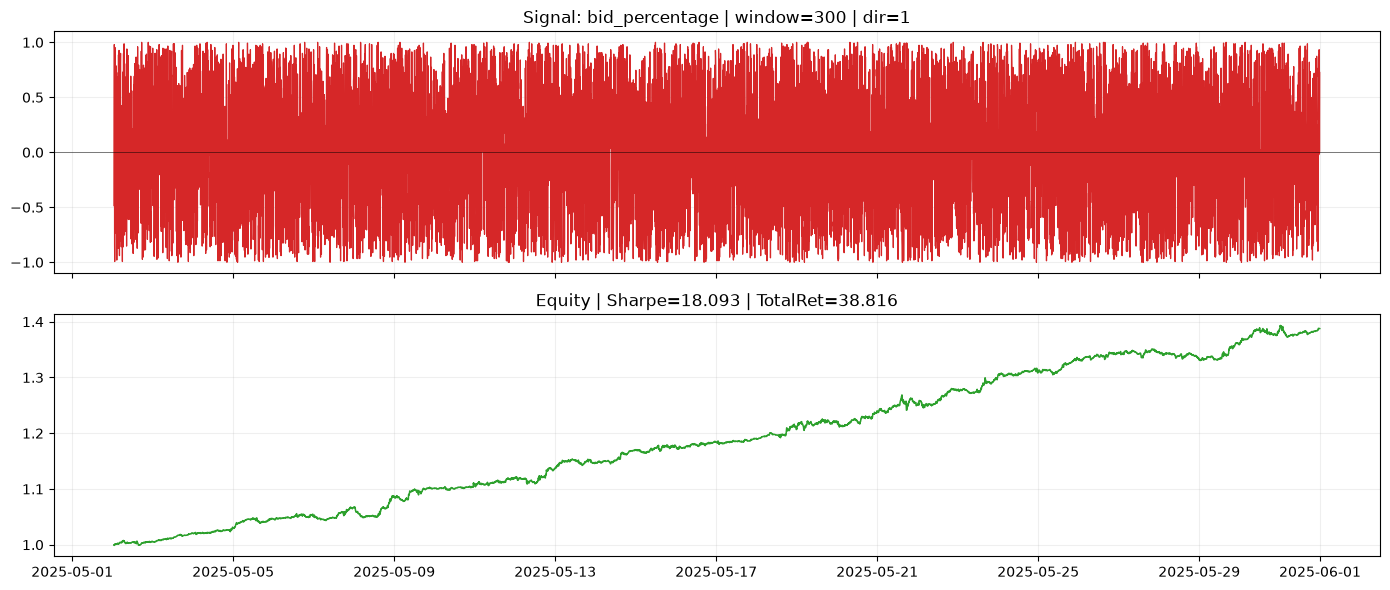

In [4]:
best = results_df.iloc[0].to_dict()
best_feature = str(best["feature"])
best_window = int(best["window"])
best_direction = int(best["direction"])

signal = make_signal(panel, best_feature, best_window) * best_direction
mask = np.isfinite(signal) & np.isfinite(forward_returns)
bt_frame, bt_summary = run_position_backtest(
    timestamps=panel.loc[mask, "time"],
    position=np.nan_to_num(np.clip(signal[mask], -1.0, 1.0), nan=0.0),
    forward_return=forward_returns[mask],
    cost_bps_one_way=COST_BPS,
)
equity = bt_frame["equity_curve"]

print("Best Strategy found:")
print(best)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(panel["time"], signal, linewidth=0.9, color="tab:red")
axes[0].axhline(0.0, color="black", linewidth=0.7, alpha=0.5)
axes[0].set_title(
    f"Signal: {best_feature} | window={best_window} | dir={best_direction}"
)
axes[0].grid(alpha=0.2)

axes[1].plot(bt_frame["timestamp"], equity, linewidth=1.1, color="tab:green")
axes[1].set_title(
    f"Equity | Sharpe={best['sharpe']:.3f} | TotalRet={best['total_return']:.3f}"
)
axes[1].grid(alpha=0.2)

fig.tight_layout()
plt.show()

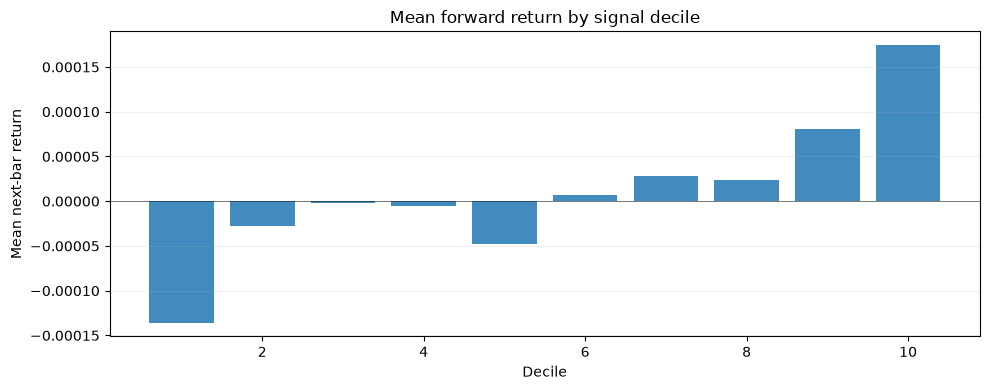

   decile  count  mean_signal  mean_fwd_ret
0       1    863    -0.900479     -0.000136
1       2    863    -0.697586     -0.000028
2       3    863    -0.499568     -0.000002
3       4    863    -0.298814     -0.000005
4       5    862    -0.097114     -0.000048
5       6    863     0.101098      0.000007
6       7    863     0.302798      0.000028
7       8    863     0.501482      0.000023
8       9    863     0.703066      0.000080
9      10    862     0.903600      0.000174


In [5]:
mask = np.isfinite(signal) & np.isfinite(forward_returns)
signal_valid = signal[mask]
returns_valid = forward_returns[mask]

if signal_valid.size == 0:
    raise RuntimeError("Best strategy produced no valid observations for decile analysis.")

order = np.argsort(signal_valid)
deciles = np.empty(signal_valid.shape[0], dtype=np.int64)
deciles[order] = (np.arange(signal_valid.shape[0]) * 10 // signal_valid.shape[0]) + 1

deciles_df = pd.DataFrame(
    [
        {
            "decile": decile,
            "count": int((decile_mask := deciles == decile).sum()),
            "mean_signal": float(np.nanmean(signal_valid[decile_mask])),
            "mean_fwd_ret": float(np.nanmean(returns_valid[decile_mask])),
        }
        for decile in range(1, 11)
    ]
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(deciles_df["decile"], deciles_df["mean_fwd_ret"], color="tab:blue", alpha=0.85)
ax.axhline(0.0, color="black", linewidth=0.7, alpha=0.5)
ax.set_title("Mean forward return by signal decile")
ax.set_xlabel("Decile")
ax.set_ylabel("Mean next-bar return")
ax.grid(alpha=0.2, axis="y")
fig.tight_layout()
plt.show()

print(deciles_df)

## Next Steps

Note that all of the backtests here are net of transaction costs.

- The metric presented here has high turnover and is most predictive on lower timeframes.
- Market microstructure metrics can be used to enhance directional strategies
  and extend existing signals.
- They can also act as regime filters to help decide when broader
  trend-following ideas are more or less effective.

Register at [Aperiodic.io](https://aperiodic.io) to run an interactive version
of this notebook
with access to all available market microstructure metrics.

